In [98]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [99]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

## Load data

In [100]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [101]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)


In [102]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# Logistic Regression

## Simple model

In [103]:
model = LogisticRegression()
model.fit(X_train_sm, y_train_sm)

LogisticRegression()

In [104]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.776     0.700     0.736       707
           1      0.673     0.753     0.711       579

    accuracy                          0.724      1286
   macro avg      0.724     0.727     0.723      1286
weighted avg      0.729     0.724     0.725      1286



### Average Precision Score

In [105]:
y_probas = model.predict_proba(X_test)[:, 1]
avg_precision = average_precision_score(y_test, y_probas)
print(f'Average Precision: {avg_precision:.3f}')

Average Precision: 0.744


### Hyperparameter Tuning

In [106]:
# params = [
#     {
#         'penalty': ['l2'],
#         'C': [0.01, 0.1, 1, 10],
#         'solver': ['liblinear', 'saga'],
#         'max_iter': [100, 500, 1000]
#     },
#     {
#         'penalty': ['l1'],
#         'C': [0.01, 0.1, 1, 10],
#         'solver': ['liblinear', 'saga'],
#         'max_iter': [100, 500, 1000]
#     },
#     {
#         'penalty': ['elasticnet'],
#         'C': [0.01, 0.1, 1, 10],
#         'solver': ['saga'],
#         'l1_ratio': [0.1, 0.5, 0.9],  # required for elasticnet
#         'max_iter': [100, 500, 1000]
#     }
# ]

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=params,
#     cv=10,
#     scoring='recall',
#     verbose=1,
#     n_jobs=-1
# )

# grid_search.fit(X_train_sm, y_train_sm)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('clf', LogisticRegression(solver='saga', max_iter=1000))
])

param_grid = {
    'clf__penalty': ['l1', 'l2', 'elasticnet'],
    'clf__C': [0.01, 0.1, 1, 10],
    # 'clf__class_weight': [None, 'balanced'],
    'clf__l1_ratio': [0.1, 0.5, 0.9]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=10,
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)


Fitting 10 folds for each of 36 candidates, totalling 360 fits


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1172: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1172: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1172: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1172: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\skle

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.3f}")

Best Parameters: {'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.773


In [ ]:
lr_tune = grid_search.best_estimator_
y_pred = lr_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, digits = 3))

Classification Report:
               precision    recall  f1-score   support

           0      0.783     0.628     0.697       707
           1      0.634     0.788     0.703       579

    accuracy                          0.700      1286
   macro avg      0.709     0.708     0.700      1286
weighted avg      0.716     0.700     0.700      1286



### Average precision

In [ ]:
y_probas_tune = lr_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.7968556749139234


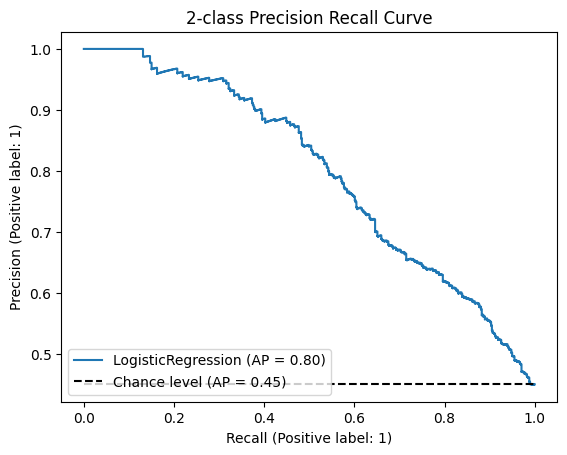

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
    lr_tune,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Confusion matrix

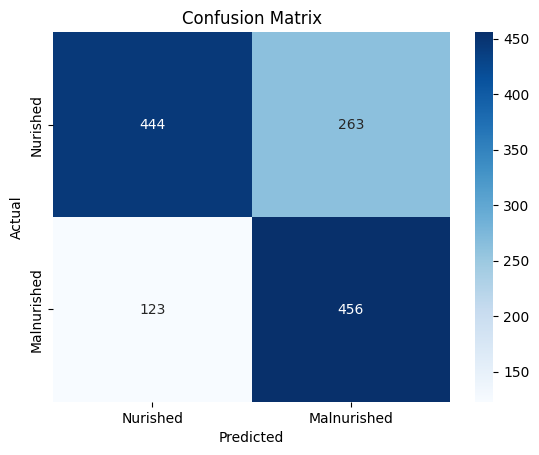

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Features importance

In [ ]:
feature_names = X_train_sm.columns

# Get coefficients
coefficients = lr_tune.coef_[0]

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance (abs)': np.abs(coefficients)
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance (abs)', ascending=False)
print(importance_df)

AttributeError: 'Pipeline' object has no attribute 'coef_'

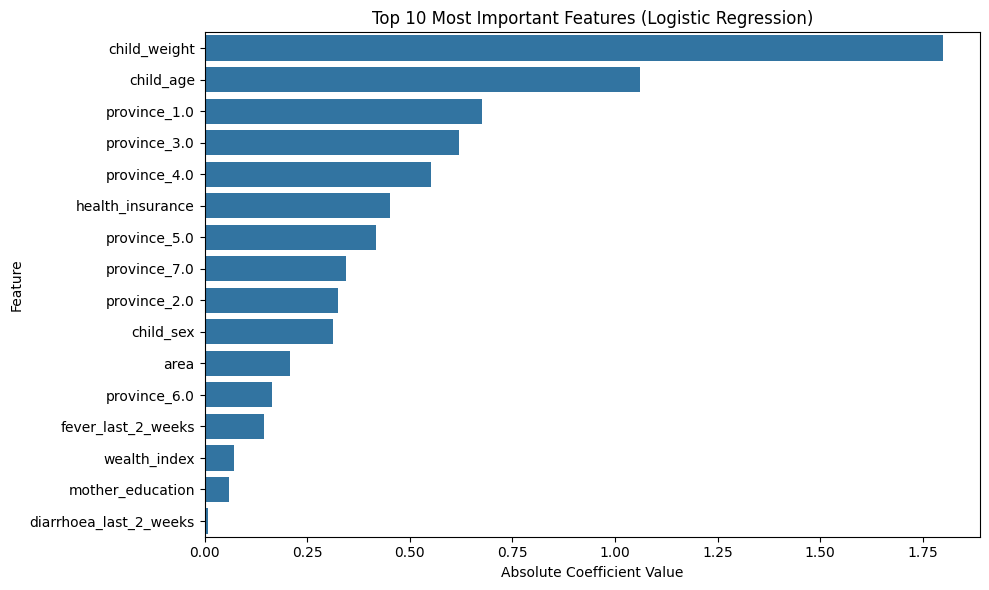

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance (abs)', y='Feature', data=importance_df.head(17))
plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Additional

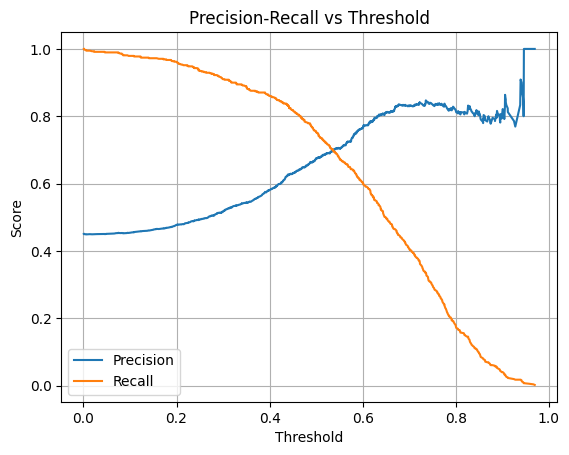

In [ ]:
y_probas = lr_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.49      0.61       707
           1       0.58      0.86      0.69       579

    accuracy                           0.66      1286
   macro avg       0.70      0.68      0.65      1286
weighted avg       0.71      0.66      0.65      1286


